# Exercise 01 - DNN + Keras Tuner

## Group members:
Elena Niero; 2200437

Eylül Çağla Ersöz; 2185017

Melissa Daniela de Almeida Nespeque; 2183904

Sahasra Sivakumar; 2183897

### Instalation of libraries and data splitting


In [6]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout
#add by me:
from keras import layers
import keras.optimizers
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow.random as tf_r
import keras_tuner

# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.8
perc_valid = 0.10
perc_test = 0.10
#  check it sums to 1 
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

### Read all datasets - N=12000; N=12000 + noise; N=9000

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 0
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: 9600
valid: 1200
test: 1200


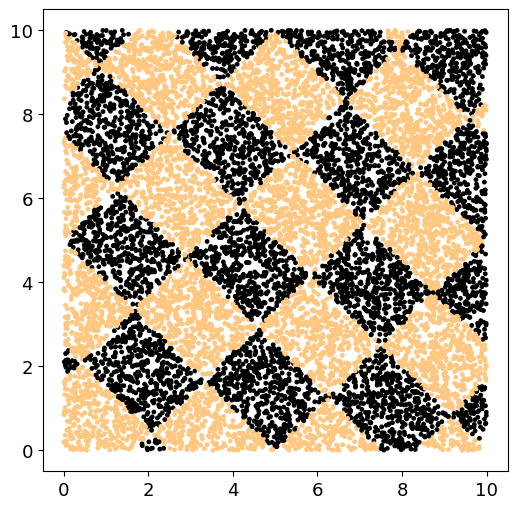

In [14]:
TYPE=4
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt('DATA/data-for-DNN_type4_L8.dat', delimiter=' ')
y = np.loadtxt('DATA/labels-for-DNN_type4_L8.dat', delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)

# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 0
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 0
data: 12000
train: 9600
valid: 1200
test: 1200


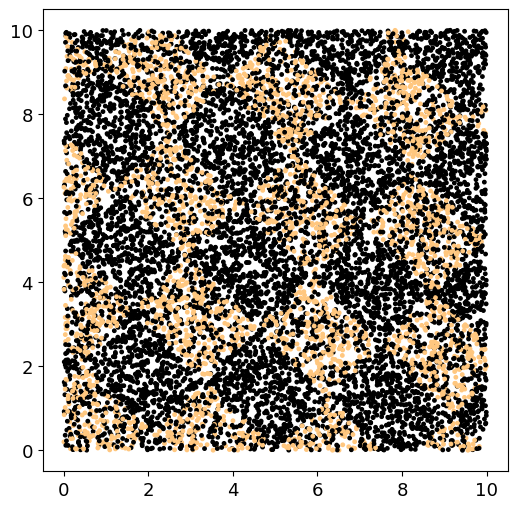

In [24]:
x_aug = np.loadtxt('DATA/data_aug0.05-for-DNN_type4_L8.dat', delimiter=' ')
y_aug = np.loadtxt('DATA/labels_aug0.05-for-DNN_type4_L8.dat', delimiter=' ')
y_aug = y_aug.astype("int")
print(x_aug.shape)
N_aug = len(x_aug)
# dim. of a sample
L = len(x_aug[0])
print(L)

for i in range(5):
    print(x_aug[i],y_aug[i])

N_train_aug = int(perc_train * N_aug)
N_valid_aug = int(perc_valid * N_aug)
N_test_aug = N_aug - N_train_aug - N_valid_aug
print(f'data: {N_aug}\ntrain: {N_train_aug}\nvalid: {N_valid_aug}\ntest: {N_test_aug}')

plot_data(x_aug,y_aug)

(9000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 0
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 9000
train: 7200
valid: 900
test: 900


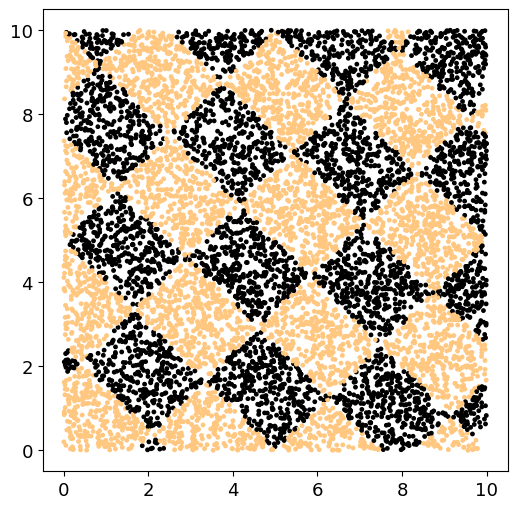

In [26]:
x_red = np.loadtxt('DATA/data-red-for-DNN_type4_L8.dat', delimiter=' ')
y_red = np.loadtxt('DATA/labels-red-for-DNN_type4_L8.dat', delimiter=' ')
y_red = y_red.astype("int")
print(x_red.shape)
N_red = len(x_red)
# dim. of a sample
L = len(x_red[0])
print(L)

for i in range(5):
    print(x_red[i],y_red[i])

N_train_red = int(perc_train * N_red)
N_valid_red = int(perc_valid * N_red)
N_test_red = N_red - N_train_red - N_valid_red
print(f'data: {N_red}\ntrain: {N_train_red}\nvalid: {N_valid_red}\ntest: {N_test_red}')

plot_data(x_red,y_red)

## Split data and standardize (fit on train only)

In [29]:
def Standardize(x,m,s):
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check 
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 9600 	 Validation: 1200 	 Test: 1200
after rescaling (train):
mean value= [ 2.03108363e-15  6.29479108e-15 -5.69839315e-15 -5.48011867e-15
 -4.38954428e-15 -3.07013674e-15 -4.04352477e-16 -1.01049493e-14] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


In [37]:
#Splitting augmented data
(x_train_aug, y_train_aug) = (x_aug[0:N_train_aug], y_aug[0:N_train_aug])
(x_valid_aug, y_valid_aug) = (x_aug[N_train_aug:N_train_aug+N_valid_aug], y_aug[N_train_aug:N_train_aug+N_valid_aug])
(x_test_aug, y_test_aug) = (x_aug[N_train_aug+N_valid_aug:],  y_aug[N_train_aug+N_valid_aug:])
#print("Train:",len(x_train_aug),"\t Validation:",len(x_valid_aug),"\t Test:",len(x_test_aug))

#mean and std:
x_train_mean_aug= np.mean(x_train_aug, axis=0)
x_train_std_aug = np.std(x_train_aug, axis=0)
x_valid_mean_aug = np.mean(x_valid_aug, axis=0)
x_valid_std_aug = np.std(x_valid_aug, axis=0)
x_test_mean_aug = np.mean(x_test_aug, axis=0)
x_test_std_aug = np.std(x_test_aug, axis=0)

#standardizing function
x_train_aug = Standardize(x_train_aug, x_train_mean_aug, x_train_std_aug)
x_valid_aug = Standardize(x_valid_aug, x_valid_mean_aug, x_valid_std_aug)
x_test_aug = Standardize(x_test_aug, x_test_mean_aug, x_test_std_aug)

#print("after rescaling (train):\nmean value=", x_train_aug.mean(axis=0), "\nstd. dev.=", x_train_aug.std(axis=0))

In [43]:
#Splitting reduced data
(x_train_red, y_train_red) = (x_red[0:N_train_red], y_red[0:N_train_red])
(x_valid_red, y_valid_red) = (x_red[N_train_red:N_train_red + N_valid_red], y_red[N_train_red:N_train_red + N_valid_red])
(x_test_red, y_test_red) = (x_red[N_train_red+N_valid_red:],  y_red[N_train_red+N_valid_red:])
print("Train:",len(x_train_red),"\t Validation:",len(x_valid_red),"\t Test:",len(x_test_red))

#mean and std:
x_train_mean_red= np.mean(x_train_red, axis=0)
x_train_std_red = np.std(x_train_red, axis=0)
x_valid_mean_red = np.mean(x_valid_red, axis=0)
x_valid_std_red = np.std(x_valid_red, axis=0)
x_test_mean_red = np.mean(x_test_red, axis=0)
x_test_std_red = np.std(x_test_red, axis=0)

#standardizing function
x_train_red = Standardize(x_train_red, x_train_mean_red, x_train_std_red)
x_valid_red = Standardize(x_valid_red, x_valid_mean_red, x_valid_std_red)
x_test_aug = Standardize(x_test_aug, x_test_mean_red, x_test_std_red)

#print("after rescaling (train):\nmean value=", x_train_red.mean(axis=0), "\nstd. dev.=", x_train_red.std(axis=0))

Train: 7200 	 Validation: 900 	 Test: 900


## Define the model with Keras / Tensorflow

In [32]:
# reproducibility (?)
np.random.seed(12345)
tf_r.set_seed(12345)

# We use case 1
CASE=1

if CASE==1: # 4 layers
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu')) # first layer : L=8 neurons
    model.add(Dense(20,activation='relu')) 
    model.add(Dropout(0.1)) # rate for neuron dropout, in order to add noise we assign a probability that a neuron
    # and its connections are dropped out. It's like training a dynamic neural network, we have randoms.
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
# as case 1 but one layer shorter
if CASE==2:
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(40,activation='relu'))
    model.add(Dropout(0.1)) 
    model.add(Dense(20,activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
#deeper
if CASE==3: #deeper neural network
    model = Sequential()
    model.add(Dense(L,input_shape=(L,),activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(10,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    nepoch=200
    
print(model.summary())

#how many parameters we have in our neural network?
# number of neurons, weigths and bias for each neuron, number of params = #input_units*#output_units + output_units
# case 1: 8*8+8 = 72
# we want to compare our num of params with the size of the dataset. We want num of total params < num of training sample otherwise 
# it's overfitting.

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 8)                 72        
                                                                 
 dense_6 (Dense)             (None, 20)                180       
                                                                 
 dropout_3 (Dropout)         (None, 20)                0         
                                                                 
 dense_7 (Dense)             (None, 20)                420       
                                                                 
 dropout_4 (Dropout)         (None, 20)                0         
                                                                 
 dense_8 (Dense)             (None, 20)                420       
                                                                 
 dropout_5 (Dropout)         (None, 20)               

In [4]:
#build function does not manually choose hyperparameters because it defines 
#the search space and the tuner picks the values during random search.
def build_model(hp):
    model = Sequential()
    
    activation = hp.Choice("activation", ["relu", "sigmoid", "elu"])
    dropout = hp.Choice("dropout", [0.0, 0.1, 0.2])
    
    model.add(Dense(L,input_shape=(L,),activation=activation)) # first layer : L=8 neurons
    #model.add(Dense(20,input_shape=(L,),activation=activation)) # chat says that this is the first hidden layer of 20 and
    # input_shape = (L,) tells that the input layer is made of L neurons automatically
    model.add(Dense(20,activation=activation)) 
    model.add(Dropout(dropout)) # rate for neuron dropout, in order to add noise we assign a probability that a neuron
    # and its connections are dropped out. It's like training a dynamic neural network, we have randoms.
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(1,activation="sigmoid"))
    #nepoch=200
    
    lr = hp.Choice("learning_rate", [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1])
    optimizer_name = hp.Choice("optimizer", ["adam","rmsprop","sgd"])

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=lr, nesterov=True)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [5]:
build_model(keras_tuner.HyperParameters())

In [6]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=10,
    #executions_per_trial=2,
    overwrite=True,
    directory="tuner_results",
    project_name="ex_1",
)

In [7]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'elu'], 'ordered': False}
dropout (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.1, 0.2], 'ordered': True}
learning_rate (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}


In [8]:
tuner.search(x_train, y_train, epochs=50, validation_data=(x_valid, y_valid))


Trial 10 Complete [00h 00m 36s]
val_accuracy: 0.9108333587646484

Best val_accuracy So Far: 0.9108333587646484
Total elapsed time: 00h 06m 45s


In [9]:
# Get the top 2 models.
models = tuner.get_best_models(num_models=2)
best_model = models[0]
best_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 72        
                                                                 
 dense_1 (Dense)             (None, 20)                180       
                                                                 
 dropout (Dropout)           (None, 20)                0         
                                                                 
 dense_2 (Dense)             (None, 20)                420       
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 dense_3 (Dense)             (None, 20)                420       
                                                                 
 dropout_2 (Dropout)         (None, 20)                0

In [10]:
tuner.results_summary()


Results summary
Results in tuner_results/ex_1
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 09 summary
Hyperparameters:
activation: elu
dropout: 0.0
learning_rate: 0.01
optimizer: adam
Score: 0.9108333587646484

Trial 05 summary
Hyperparameters:
activation: elu
dropout: 0.1
learning_rate: 0.001
optimizer: rmsprop
Score: 0.565833330154419

Trial 01 summary
Hyperparameters:
activation: elu
dropout: 0.1
learning_rate: 0.0001
optimizer: adam
Score: 0.5450000166893005

Trial 08 summary
Hyperparameters:
activation: elu
dropout: 0.2
learning_rate: 1e-05
optimizer: adam
Score: 0.5299999713897705

Trial 02 summary
Hyperparameters:
activation: sigmoid
dropout: 0.2
learning_rate: 0.0001
optimizer: rmsprop
Score: 0.5074999928474426

Trial 00 summary
Hyperparameters:
activation: elu
dropout: 0.1
learning_rate: 0.1
optimizer: adam
Score: 0.5024999976158142

Trial 03 summary
Hyperparameters:
activation: sigmoid
dropout: 0.1
learning_rate: 0.0001
optimizer: sgd
Score: 0

In [17]:
# Get the top 2 hyperparameters.
best_hps = tuner.get_best_hyperparameters(5)
# Build the model with the best hp.
model = build_model(best_hps[0])
# Fit with the entire dataset.
#x_all = np.concatenate((x_train, x_valid))
#y_all = np.concatenate((y_train, y_valid))
#fit = model.fit(x=x_all, y=y_all, epochs=200)
fit = model.fit(x_train, y_train,
               epochs = 200, batch_size = 50, #size on which we are doing the gradients (batch_size= size of mini batches, the larger is batch size, the smoothest is our gradient, the smaller is the noisier is our gradient)
               validation_data=(x_valid,y_valid),
               verbose=2)

Epoch 1/200
192/192 - 1s - loss: 0.6964 - accuracy: 0.5116 - val_loss: 0.6924 - val_accuracy: 0.5058 - 1s/epoch - 6ms/step
Epoch 2/200
192/192 - 0s - loss: 0.6929 - accuracy: 0.5142 - val_loss: 0.6901 - val_accuracy: 0.5208 - 447ms/epoch - 2ms/step
Epoch 3/200
192/192 - 0s - loss: 0.6922 - accuracy: 0.5120 - val_loss: 0.6887 - val_accuracy: 0.5208 - 339ms/epoch - 2ms/step
Epoch 4/200
192/192 - 0s - loss: 0.6884 - accuracy: 0.5264 - val_loss: 0.6869 - val_accuracy: 0.5158 - 398ms/epoch - 2ms/step
Epoch 5/200
192/192 - 0s - loss: 0.6861 - accuracy: 0.5324 - val_loss: 0.6864 - val_accuracy: 0.5392 - 456ms/epoch - 2ms/step
Epoch 6/200
192/192 - 0s - loss: 0.6831 - accuracy: 0.5340 - val_loss: 0.6843 - val_accuracy: 0.5275 - 436ms/epoch - 2ms/step
Epoch 7/200
192/192 - 0s - loss: 0.6849 - accuracy: 0.5327 - val_loss: 0.6817 - val_accuracy: 0.5500 - 342ms/epoch - 2ms/step
Epoch 8/200
192/192 - 0s - loss: 0.6842 - accuracy: 0.5328 - val_loss: 0.6848 - val_accuracy: 0.5217 - 334ms/epoch - 2ms/

Epoch 66/200
192/192 - 0s - loss: 0.1928 - accuracy: 0.9167 - val_loss: 0.2222 - val_accuracy: 0.8967 - 441ms/epoch - 2ms/step
Epoch 67/200
192/192 - 0s - loss: 0.1770 - accuracy: 0.9207 - val_loss: 0.2188 - val_accuracy: 0.9025 - 494ms/epoch - 3ms/step
Epoch 68/200
192/192 - 0s - loss: 0.1828 - accuracy: 0.9205 - val_loss: 0.1900 - val_accuracy: 0.9042 - 398ms/epoch - 2ms/step
Epoch 69/200
192/192 - 0s - loss: 0.1711 - accuracy: 0.9243 - val_loss: 0.1730 - val_accuracy: 0.9208 - 476ms/epoch - 2ms/step
Epoch 70/200
192/192 - 0s - loss: 0.1847 - accuracy: 0.9170 - val_loss: 0.2128 - val_accuracy: 0.9125 - 385ms/epoch - 2ms/step
Epoch 71/200
192/192 - 0s - loss: 0.1898 - accuracy: 0.9151 - val_loss: 0.1656 - val_accuracy: 0.9133 - 396ms/epoch - 2ms/step
Epoch 72/200
192/192 - 0s - loss: 0.1764 - accuracy: 0.9196 - val_loss: 0.1460 - val_accuracy: 0.9383 - 478ms/epoch - 2ms/step
Epoch 73/200
192/192 - 0s - loss: 0.1760 - accuracy: 0.9232 - val_loss: 0.2003 - val_accuracy: 0.9008 - 447ms/e

Epoch 131/200
192/192 - 1s - loss: 0.1587 - accuracy: 0.9322 - val_loss: 0.1920 - val_accuracy: 0.9183 - 633ms/epoch - 3ms/step
Epoch 132/200
192/192 - 0s - loss: 0.1509 - accuracy: 0.9339 - val_loss: 0.1585 - val_accuracy: 0.9292 - 413ms/epoch - 2ms/step
Epoch 133/200
192/192 - 0s - loss: 0.1490 - accuracy: 0.9352 - val_loss: 0.1724 - val_accuracy: 0.9208 - 459ms/epoch - 2ms/step
Epoch 134/200
192/192 - 0s - loss: 0.1494 - accuracy: 0.9341 - val_loss: 0.1563 - val_accuracy: 0.9350 - 456ms/epoch - 2ms/step
Epoch 135/200
192/192 - 0s - loss: 0.1648 - accuracy: 0.9286 - val_loss: 0.1784 - val_accuracy: 0.9250 - 413ms/epoch - 2ms/step
Epoch 136/200
192/192 - 0s - loss: 0.1604 - accuracy: 0.9305 - val_loss: 0.1903 - val_accuracy: 0.9150 - 439ms/epoch - 2ms/step
Epoch 137/200
192/192 - 0s - loss: 0.1559 - accuracy: 0.9296 - val_loss: 0.2242 - val_accuracy: 0.9083 - 255ms/epoch - 1ms/step
Epoch 138/200
192/192 - 0s - loss: 0.1614 - accuracy: 0.9296 - val_loss: 0.1837 - val_accuracy: 0.9158 -

192/192 - 0s - loss: 0.1468 - accuracy: 0.9368 - val_loss: 0.1560 - val_accuracy: 0.9225 - 387ms/epoch - 2ms/step
Epoch 196/200
192/192 - 0s - loss: 0.1329 - accuracy: 0.9429 - val_loss: 0.2179 - val_accuracy: 0.9142 - 266ms/epoch - 1ms/step
Epoch 197/200
192/192 - 0s - loss: 0.1422 - accuracy: 0.9382 - val_loss: 0.2021 - val_accuracy: 0.9108 - 392ms/epoch - 2ms/step
Epoch 198/200
192/192 - 0s - loss: 0.1460 - accuracy: 0.9356 - val_loss: 0.1667 - val_accuracy: 0.9275 - 444ms/epoch - 2ms/step
Epoch 199/200
192/192 - 0s - loss: 0.1428 - accuracy: 0.9398 - val_loss: 0.1583 - val_accuracy: 0.9233 - 394ms/epoch - 2ms/step
Epoch 200/200
192/192 - 0s - loss: 0.1393 - accuracy: 0.9382 - val_loss: 0.1808 - val_accuracy: 0.9175 - 499ms/epoch - 3ms/step


## Optimization method and cost function

In [29]:
#now we have to define the cost function and the optimization method (we have binary classification => loss function is binary cross entropy)
#model.compile(loss='binary_crossentropy',
 #             optimizer='RMSprop',
              #optimizer='adam',
  #            metrics=['accuracy']) #metrics with wich our model is correct. Accuracy = # of predictions/# of total predictions
# = (TP+TN)/(TP+TN+FP+FN)

## Training

In [18]:
#fit = model.fit(x_train, y_train,
 #              epochs = nepoch, batch_size = 50, #size on which we are doing the gradients (batch_size= size of mini batches, the larger is batch size, the smoothest is our gradient, the smaller is the noisier is our gradient)
  #             validation_data=(x_valid,y_valid),
   #            verbose=2)
# for each epoch we print loss (binary cross entropy) and accuracy (numb of correct pred/tot pred)

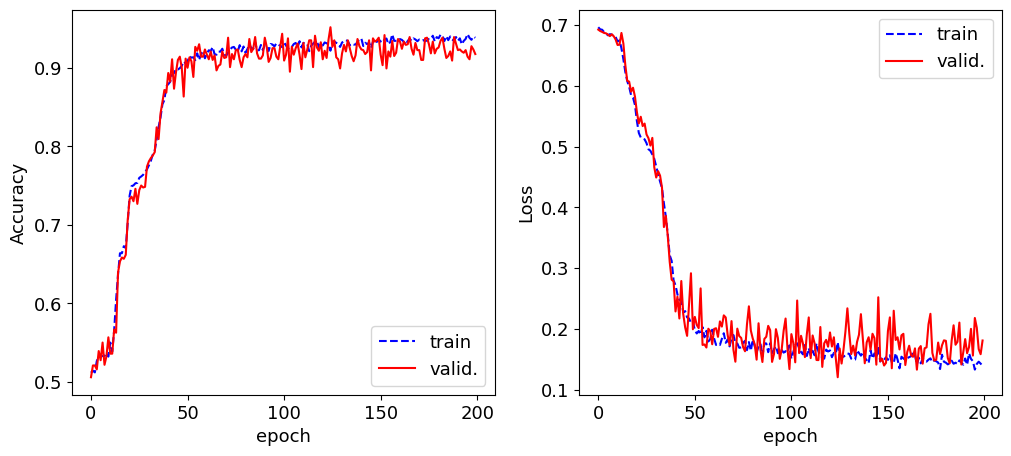

In [19]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

# we want the train and valid to go toghether (is what we aim for), the signature of overfitting ids the gap between train and valid loss,
# in the case of underfitting we see that the accuracy does not increases.
# when our loss is around 0.7 we have a random number generator, we always strart from 0.7! (make the count we the cross entropy formula)

# Evaluation on the test set


In [20]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.2432
Final test accuracy: 0.8975


## Grid to show preditions

319/319 [==============================] - 0s 1ms/step


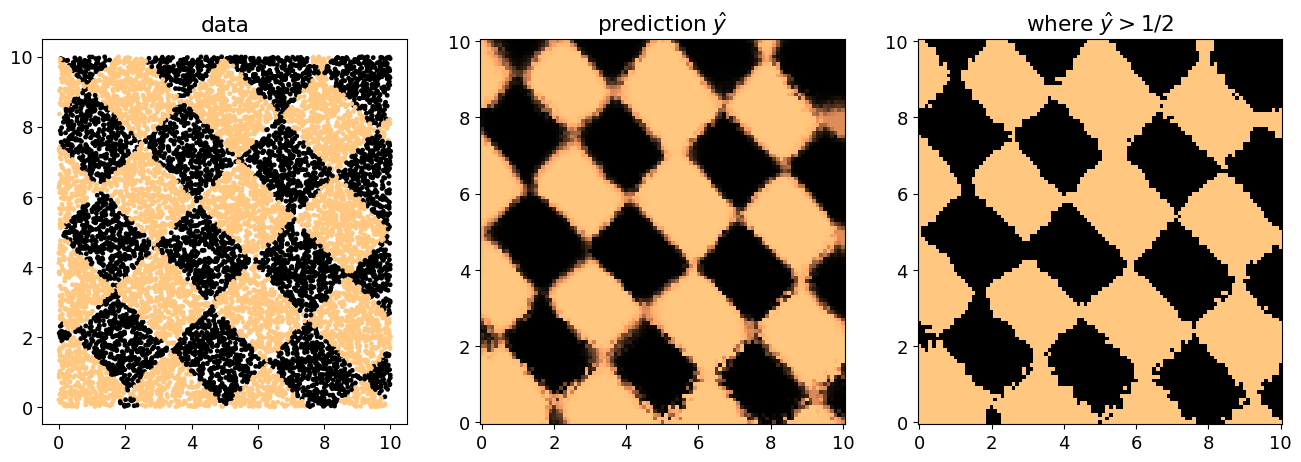

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [21]:
# we use neural network on a 10*10 grid, we create a colormap from 0 to 1 in fig 2 and a map we just 0 or 1 in fig 3
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")

In [ ]:
#assume we are in overfitting regim : we reduce parameters (reduce model capacity), randomize (through dropout), early stopping 
#(to be implement)
#assume we are underfitting regim : increase model capacity, less dropout, tune optimizer (learning rate)